<center><img src='https://raw.githubusercontent.com/Jangrae/img/master/satisfaction.png'/></center>

### **고객 만족도 예측을 통한 서비스 개선**
# **단계 1: 데이터 분석**

## **미션 설명**

- 이번 단계에서는 다음과 같이 5개의 미션을 수행합니다.

### 미션 1: 기본 탐색 및 전처리

- 분석 대상 데이터를 읽어와 기본적인 탐색을 수행합니다.
- 결측치 존재 여부를 확인하고 적절한 방법으로 처리합니다.
- Target 값을 숫자로 변경합니다.
- 분석에 불필요한 변수를 제거합니다.

### 미션 2: 가설 수립과 검증

- 탐색 과정을 통해 얻은 정보로 가설을 수립합니다.
- 데이터 시각화 분석을 통해 수립한 가설을 검증합니다.
- 모든 분석 과정에 대한 의견을 정리합니다.
- 정리된 의견은 팀 프로젝트 수행 시 발표 자료에 정리합니다.


### 미션 3: 머신러닝 모델링 #1

- 머신러닝 모델을 만들어 성능을 평가합니다.
- 변수 중요도를 확인하고 의견으로 정리합니다.

### 미션 4: 머신러닝 모델링 #2

- 데이터를 두 개로 분리합니다.
- 각각의 데이터에 대해 별도의 모델을 만들어 성능을 평가합니다.
- 각각의 모델이 중요하다고 판단한 변수를 확인하고 정리합니다.

### 미션 5: 데이터 분석

- 모델링 과정을 통해 얻은 통찰력으로 분석 대상 변수를 선택합니다.
- 선택한 변수에 대한 분석을 수행하고 결과를 의견으로 정리합니다.

## **※ 코드 셀은 충분히 추가해 사용합니다.**

## **1. 환경설정**

### (1) 구글 드라이브 연결 및 경로 설정

- 구글 드라이브에 **project01** 폴더를 만들고 배포한 파일을 업로드합니다.
- 다음 구문을 실행에 구글 코랩에서 사용 가능하게 연결합니다.

In [603]:
# 구글 드라이브 연결 & 패스 지정
import sys
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')
    path = '/content/drive/MyDrive/project01/'
else:
    path = ''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### (2) 라이브러리 불러오기

- 이후에 사용할 라이브러리를 모두 불러옵니다.

In [604]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import *
from sklearn.ensemble import RandomForestClassifier

import joblib
import warnings

warnings.filterwarnings(action='ignore')
%config InlineBackend.figure_format='retina'

### (3) 데이터 불러오기

- 다음 파일을 읽어와 **data** 데이터프레임을 만듭니다.
    - path + 'survey.csv' → data

In [605]:
# 파일 읽어오기
file = path + 'survey.csv'
data = pd.read_csv(file)

## **2. 미션 1: 기본 탐색 및 전처리**

### (1) 기본정보 확인

- 데이터 형태, 기초통계량 등을 확인합니다.

In [606]:
data.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


In [607]:
data.describe()

,Unnamed: 0,ID,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,19278.000000,19278.000000,18626.000000,19278.000000,18640.000000,19278.000000,19278.000000,19278.000000,18893.000000,19278.000000,18791.000000,19278.000000,19278.000000,19278.000000,19278.000000,19278.00000,19278.000000,19278.000000,19278.000000,19224.000000
mean,51926.605716,65515.708580,41.424783,1474.563544,3.094528,2.985631,2.989159,2.989003,3.451596,3.887955,3.876111,3.853512,3.776118,3.734983,3.905644,3.58891,3.914981,3.658004,12.802832,12.833645
std,30134.716545,37481.228258,13.166125,1117.574556,1.541379,1.542553,1.540798,1.353441,1.260715,1.251155,1.193953,1.150868,1.170431,1.214783,1.118987,1.18149,1.116209,1.187601,34.104475,34.531938
min,13.000000,4.000000,7.000000,56.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,1.000000,1.000000,0.000000,0.000000
25%,25716.500000,33204.750000,32.000000,495.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.00000,3.000000,3.000000,0.000000,0.000000
50%,51992.500000,65640.500000,43.000000,1119.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,4.000000,0.000000,0.000000
75%,78115.250000,97865.250000,51.000000,2321.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,9.000000,9.000000
max,103901.000000,129867.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,933.000000,920.000000


In [608]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 25 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         19278 non-null  int64  
 1   ID                                 19278 non-null  int64  
 2   Gender                             19278 non-null  object 
 3   Customer Type                      19278 non-null  object 
 4   Age                                18626 non-null  float64
 5   Type of Travel                     19278 non-null  object 
 6   Class                              19278 non-null  object 
 7   Flight Distance                    19278 non-null  int64  
 8   Inflight wifi service              18640 non-null  float64
 9   Departure/Arrival time convenient  19278 non-null  int64  
 10  Ease of Online booking             19278 non-null  int64  
 11  Gate location                      19278 non-null  int

### (2) Target 변수 확인

- Target인 **Satisfaction** 변수에 대해 단변량 분석을 수행합니다.

In [609]:
data['Satisfaction'].value_counts()


,count
Satisfaction,
Satisfied,17293
Neutral or Dissatisfied,1985


### (3) 결측치 확인

- 결측치 비율을 기준으로 내림차순 정렬해 확인합니다.

In [610]:
data.isnull().mean().sort_values(ascending=False)

,0
Age,0.033821
Inflight wifi service,0.033095
Seat comfort,0.025262
Food and drink,0.019971
Arrival Delay in Minutes,0.002801
Customer Type,0.000000
Unnamed: 0,0.000000
Gender,0.000000
ID,0.000000
Flight Distance,0.000000


### (4) 결측치 채우기

- 결측치가 있는 수치형 변수는 **중앙값**으로, 범주형 변수는 **최빈값**으로 채웁니다.
    - 수치형 변수: 'Age', 'Arrival Delay in Minutes'
    - 범주형 변수: 'Inflight wifi service', 'Seat comfort', 'Food and drink'
- 추천: 이후 확장성을 위해 범주형/수치형 변수를 자동 선택하고, 결측치를 일괄 처리합니다.

In [611]:
# 수치형 변수 선택
num_cols = ['Age', 'Arrival Delay in Minutes']

# 결측치 → 중앙값
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

data.isnull().sum()


,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,638
Departure/Arrival time convenient,0


In [612]:
# 범주형 변수 선택
cat_cols = ['Inflight wifi service','Seat comfort','Food and drink']

# 결측치 → 최빈값
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().loc[0])

data.isnull().sum()


,0
Unnamed: 0,0
ID,0
Gender,0
Customer Type,0
Age,0
Type of Travel,0
Class,0
Flight Distance,0
Inflight wifi service,0
Departure/Arrival time convenient,0


In [613]:
data.head()

,Unnamed: 0,ID,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,80396,16087,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,...,5,4,2,2,3,1,5,0,0.0,Satisfied
1,20716,125832,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,...,4,4,4,4,5,4,5,10,3.0,Satisfied
2,29653,40743,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,...,4,4,4,4,2,4,4,21,7.0,Satisfied
3,94582,46572,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,...,3,2,5,5,5,4,5,142,158.0,Satisfied
4,17127,32593,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,...,3,3,4,1,1,2,3,0,0.0,Satisfied


### (5) Target 값 변경

- Target인 **Satisfaction** 변수  값을 1과 0으로 변경합니다.
    - 'Satisfied'--> 1,
    - 'Neutral or Dissatisfied' --> 0
- **map()** 메서드를 사용합니다.

In [614]:
# 실제 값 확인
print(data['Satisfaction'].unique())

['Satisfied' 'Neutral or Dissatisfied']


In [615]:
encoder = LabelEncoder()

data['Satisfaction'] = data['Satisfaction'].map({'Satisfied':1, 'Neutral or Dissatisfied':0})

### (6) 불필요한 변수 제거

- 다음 변수는 분석에 의미가 없으므로 제거합니다.
    - 'Unnamed: 0'
    - 'ID'

In [616]:
drop_cols = ['Unnamed: 0', 'ID']
data.drop(columns=drop_cols, inplace=True)

data.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,Male,Loyal Customer,35.0,Business Travel,Eco,349,5.0,1,1,1,...,5,4,2,2,3,1,5,0,0.0,1
1,Female,Loyal Customer,40.0,Business Travel,Business,920,1.0,1,1,1,...,4,4,4,4,5,4,5,10,3.0,1
2,Female,Loyal Customer,52.0,Business Travel,Business,3979,1.0,1,1,1,...,4,4,4,4,2,4,4,21,7.0,1
3,Male,Loyal Customer,47.0,Business Travel,Eco,141,5.0,3,3,3,...,3,2,5,5,5,4,5,142,158.0,1
4,Male,Loyal Customer,33.0,Business Travel,Business,3153,0.0,5,0,4,...,3,3,4,1,1,2,3,0,0.0,1


## **3. 미션 2: 가설 수립과 검증**

### (1) 가설 수립

- 'ㅇㅇ이면 ㅇㅇ일 것이다' 라는 형식의 가설을 5개 이상 세워봅니다.
- 이후 분석 과정을 통해 수립한 가설을 검증합니다.
- 특히 이변량 분석을 통해 가설을 검증하도록 합니다.

In [617]:
# 가설 1: 이코노미클래스의 승객의 빈도가 제일 높을 것. (비즈니스클래스의 만족도가 이코노미클래스의 만족도보다 높을것)
# 가설 2: 도착 지연 시간이 길수록 만족도가 낮을 것.
# 가설 3: gate location 의 숫자가 적을수록 만족도가 높을 것.
# 가설 4: 나이가 많을수록 만족도가 낮을 것.
# 가설 5: 여행 거리가 길수록 만족도가 낮을 것.

### (2) 단변량 분석

- 5개 이상의 변수에 대한 단변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

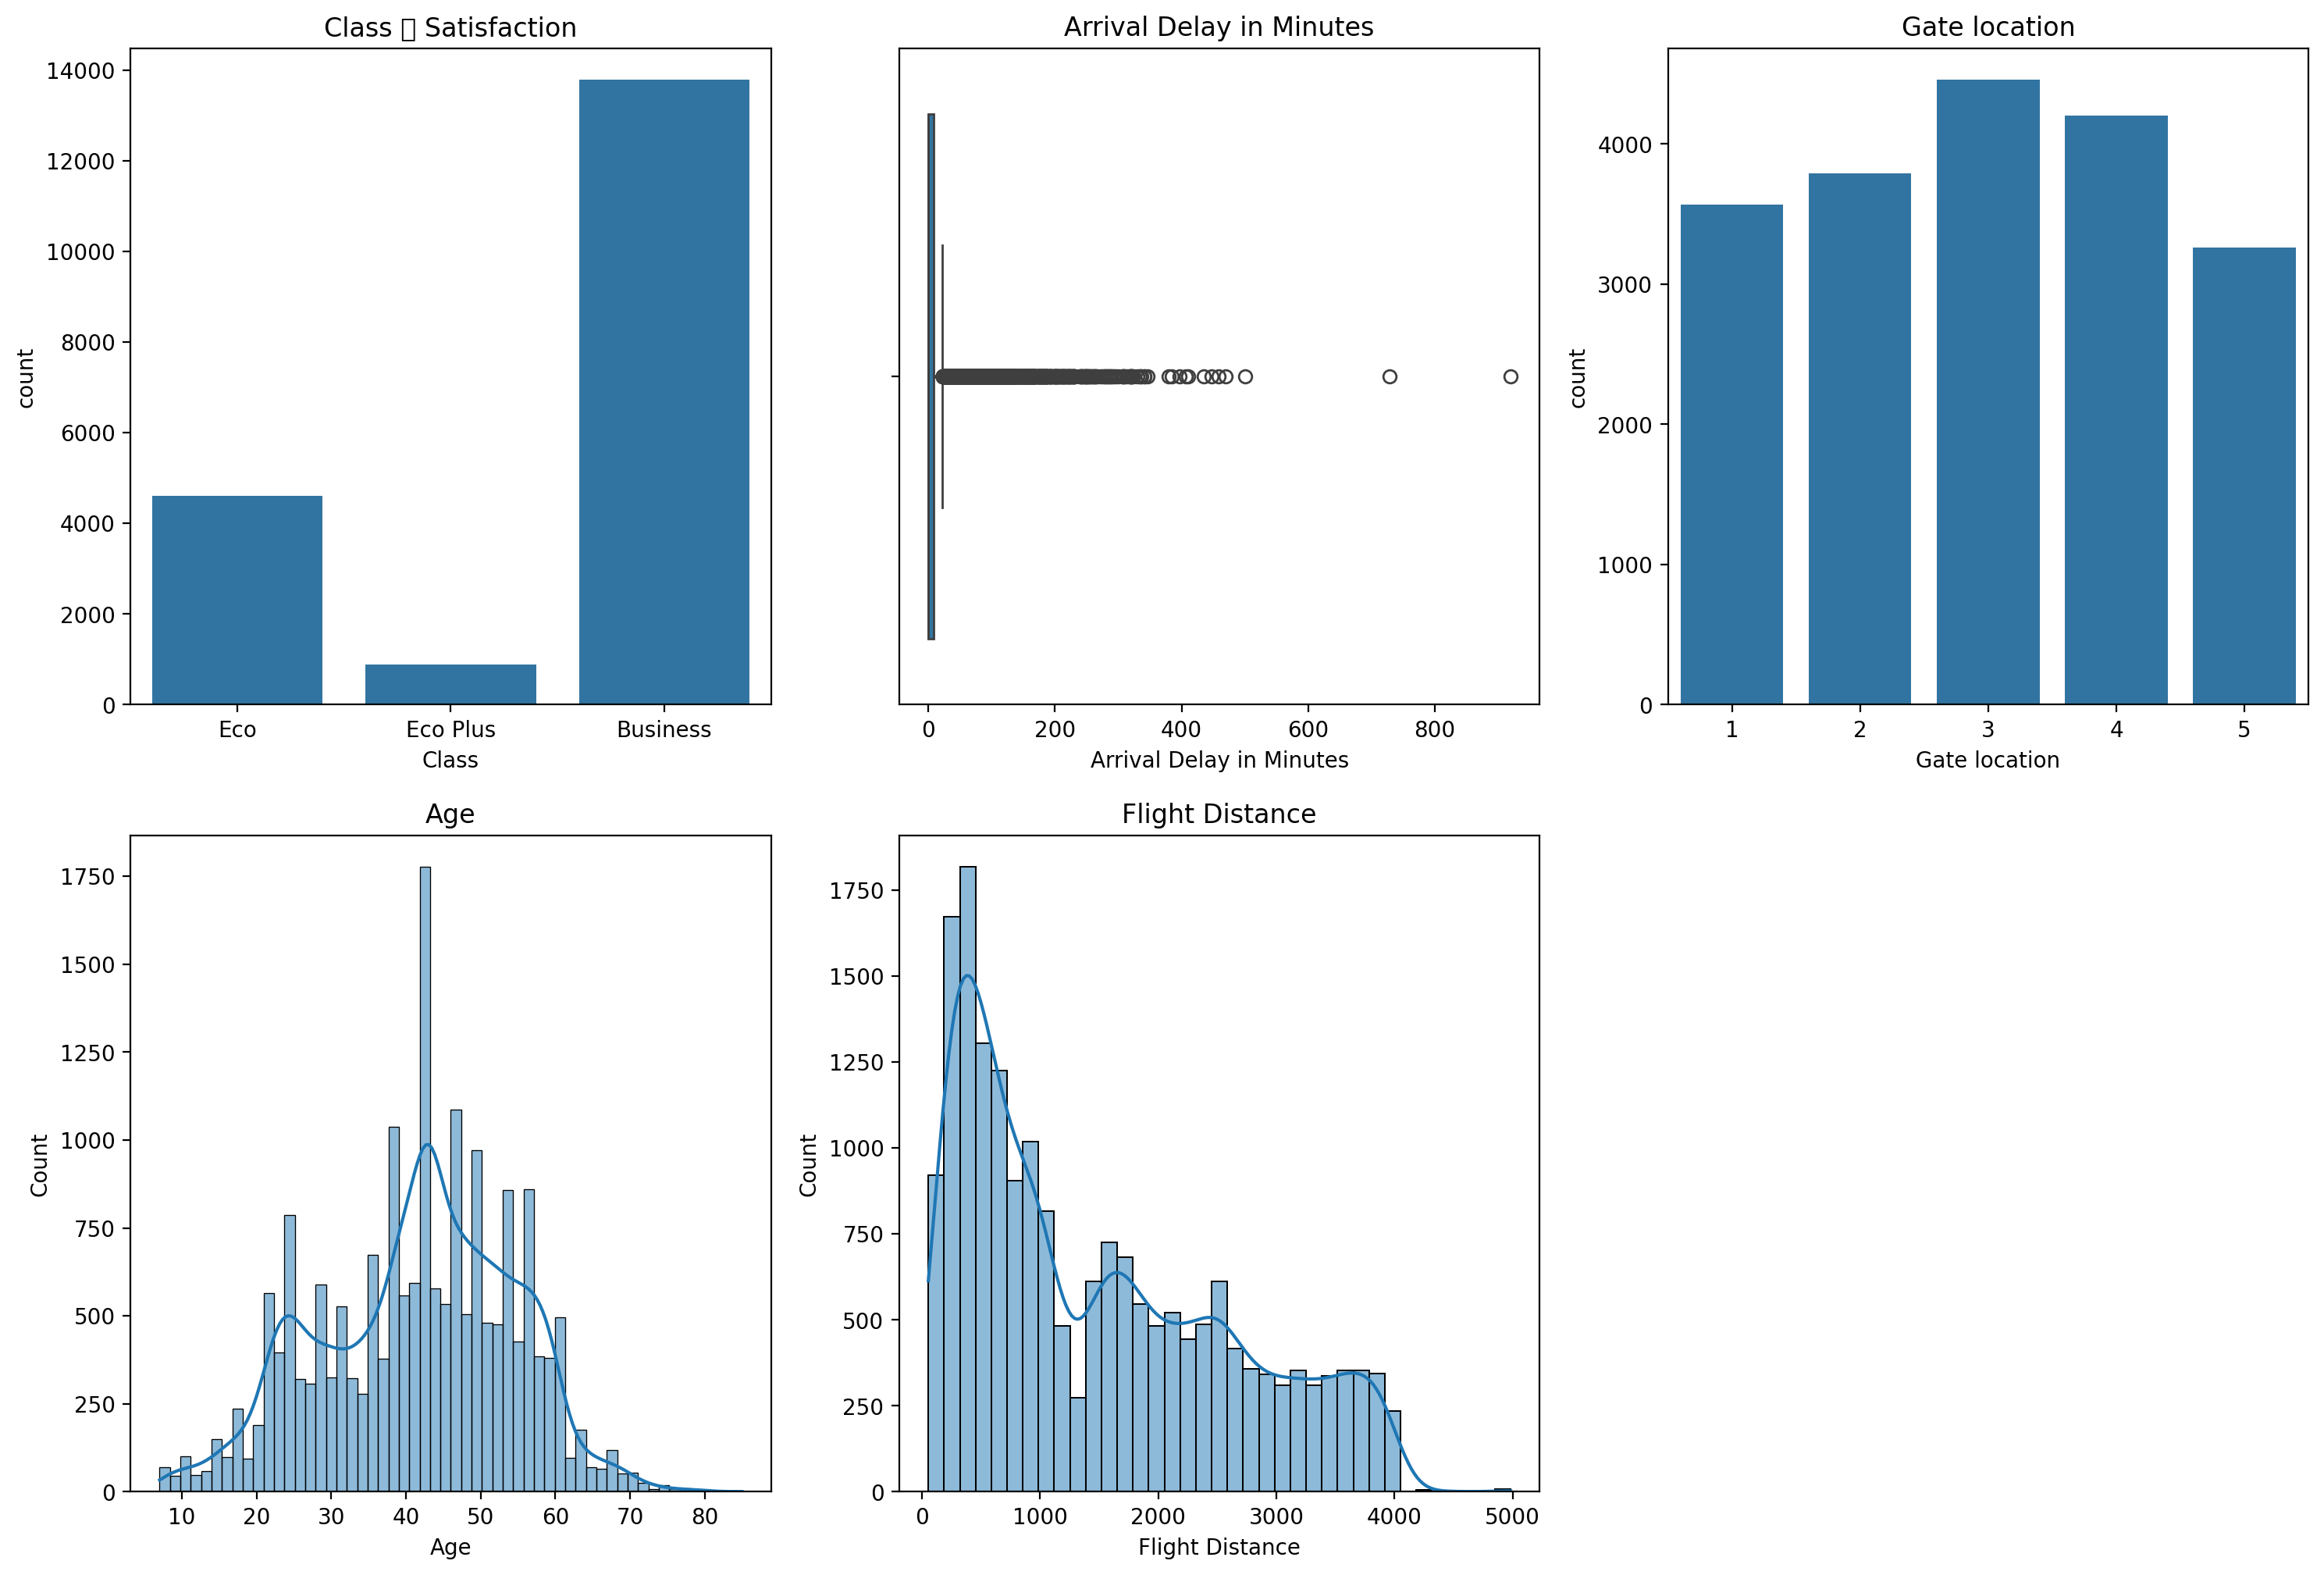

In [618]:
plt.figure(figsize=(18,12))
plt.subplot(2,3,1)
sns.countplot(x='Class', data=data, order=['Eco', 'Eco Plus', 'Business'])
plt.title('Class 별 Satisfaction')

plt.subplot(2,3,2)
sns.boxplot(x=data['Arrival Delay in Minutes'])
plt.title('Arrival Delay in Minutes')

plt.subplot(2,3,3)
sns.countplot(x='Gate location', data=data, order=['1','2','3','4','5'])
plt.title('Gate location')

plt.subplot(2,3,4)
sns.histplot(data['Age'], kde=True)
plt.title('Age')

plt.subplot(2,3,5)
sns.histplot(data['Flight Distance'], kde=True)
plt.title('Flight Distance')

plt.show()


# 의견:
# 1. business class 승객이 압도적으로 많다.
# 2. arrival delay in minutes 에서는 극단적으로 도착지연시간이 생긴 승객이 몇 사람 있다.
# 3. gate location 은 고루 분포되어있다.
# 4. 승객의 나이대는 다양하고, 40~50대 승객이 제일 많다.
# 5. 비행거리가 길수록 그 수가 적어진다.

### (3) 이변량 분석

- 5개 이상의 이변량 분석을 수행합니다.
- 각 분석에 대한 의견을 주석으로 정리합니다.

In [619]:
print(data['Satisfaction'].value_counts())
print(data['Satisfaction'].dtype)

Satisfaction
1    17293
0     1985
Name: count, dtype: int64
int64


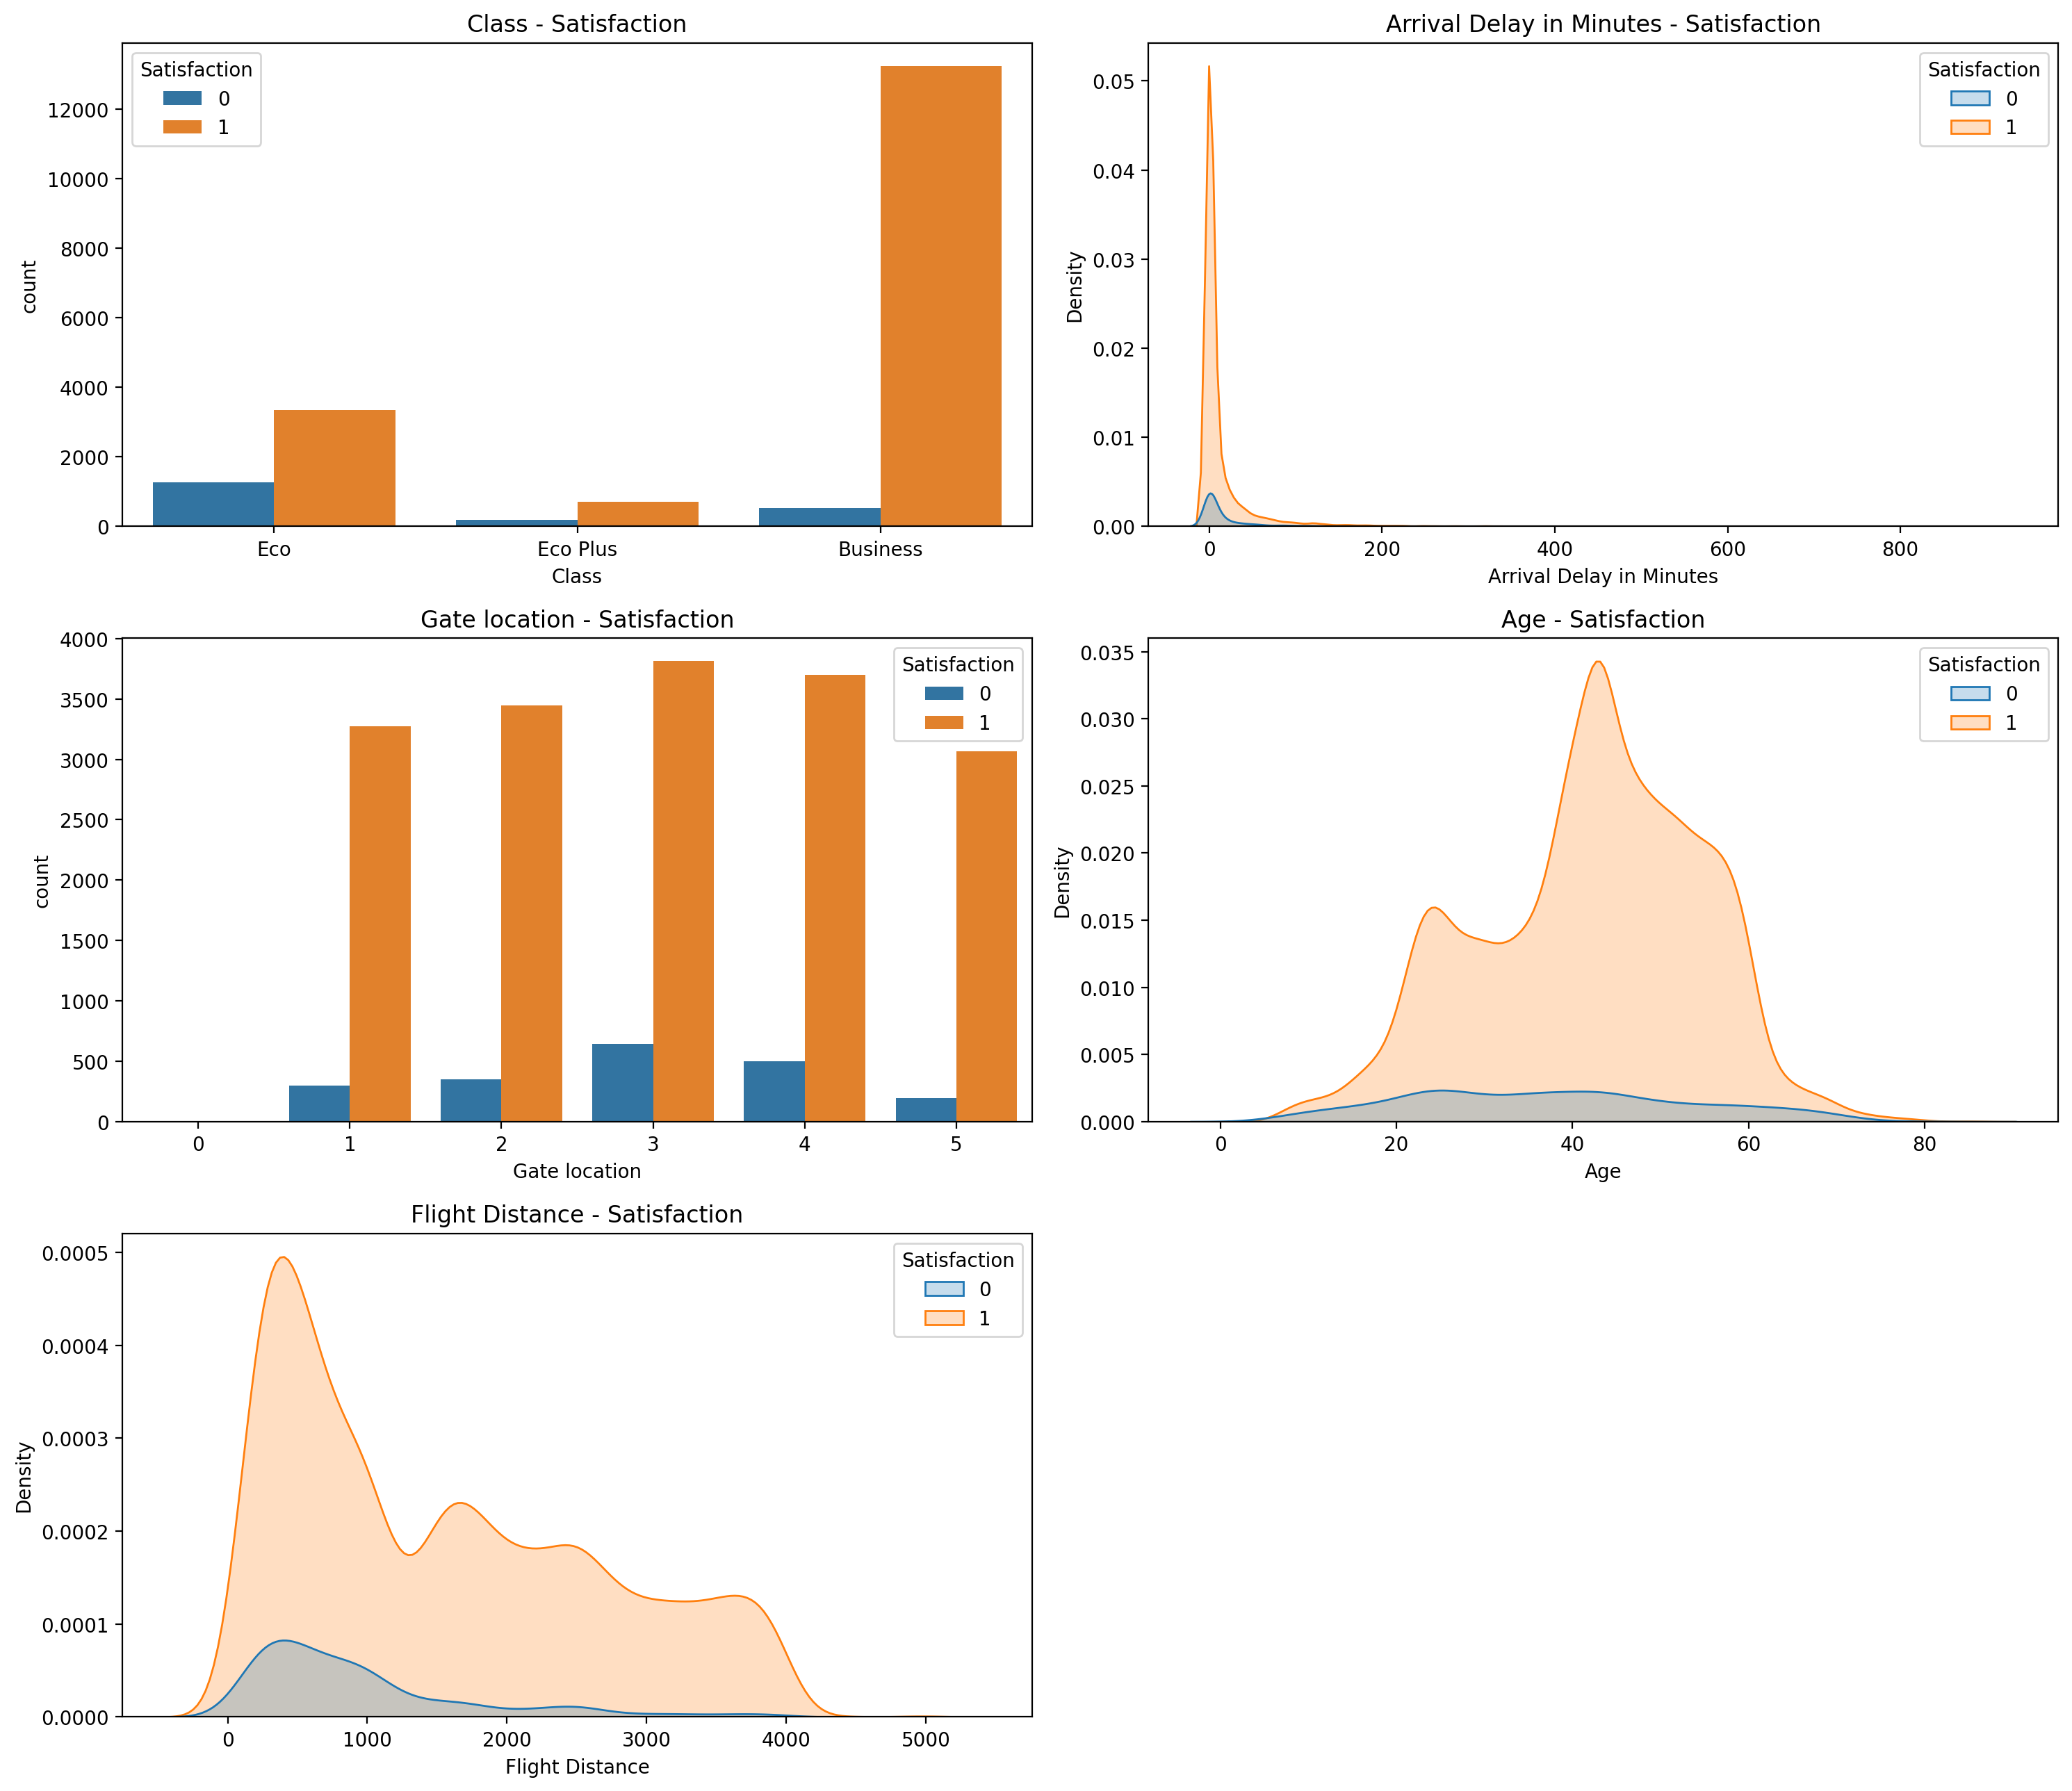

In [620]:
plt.figure(figsize=(15,13))

plt.subplot(3,2,1)
sns.countplot(x='Class', hue='Satisfaction', data=data, order=['Eco', 'Eco Plus', 'Business'])
plt.title('Class - Satisfaction')

plt.subplot(3,2,2)
sns.kdeplot(x='Arrival Delay in Minutes', hue='Satisfaction', data=data, fill=True)
plt.title('Arrival Delay in Minutes - Satisfaction')

plt.subplot(3,2,3)
sns.countplot(x='Gate location', hue='Satisfaction', data=data)
plt.title('Gate location - Satisfaction')

plt.subplot(3,2,4)
sns.kdeplot(x='Age', hue='Satisfaction', data=data, fill=True)
plt.title('Age - Satisfaction')

plt.subplot(3,2,5)
sns.kdeplot(x='Flight Distance', hue='Satisfaction', data=data, fill=True)
plt.title('Flight Distance - Satisfaction')

plt.tight_layout()
plt.show()

# 의견
# 1. 확실히 business클래스 승객의 satisfied 비율이 높음.
# 2. 도착지연시간 0분의 데이터가 너무 많아 판단이 어려움.
# 3. Gate location과 satisfaction은 큰 상관관계는 없어보임
# 4. Age와 satisfaction은 큰 상관관계는 없어보인다.
# 5. Flight Distance 가 길수록 satisfied 의 비율이 높아지는 걸로 보임.

## **4. 미션 3: 머신러닝 모델링 #1**

- Tree 기반 알고리즘을 사용해야 **변수 중요도**를 확인할 수 있습니다.
- **RandomForest** 알고리즘을 사용해 머신러닝 모델을 만들고 성능을 평가합니다.
- **변수 중요도**를 확인해 추가 분석 대상 변수를 선정합니다.

### (1) 전처리

- 최소한 문자열 데이터가 없어야 하고, 결측치도 없도록 전처리해야 합니다.
- 결측치는 이전 단계에서 처리한 상태입니다.
- 범주형 변수에 대해 **LabelEncoder**를 사용해 인코딩합니다.
- 변수 중요도를 확인하기 위함이므로 가변수화를 하지 않습니다.

In [621]:
# 변수 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  object 
 1   Customer Type                      19278 non-null  object 
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  object 
 4   Class                              19278 non-null  object 
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

In [622]:
# 문자열 변수 리스트로 선언
cat_cols =  ['Gender','Customer Type','Type of Travel','Class']

# 라벨 인코딩
for col in cat_cols:
    encoder = LabelEncoder()
    data[col] = encoder.fit_transform(data[col])

- info() 메서드로 변수 정보를 다시 확인합니다.
- **Dtype에 object 형식의 열이 있으면 이후 과정을 진행할 수 없습니다.**

In [623]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19278 entries, 0 to 19277
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             19278 non-null  int64  
 1   Customer Type                      19278 non-null  int64  
 2   Age                                19278 non-null  float64
 3   Type of Travel                     19278 non-null  int64  
 4   Class                              19278 non-null  int64  
 5   Flight Distance                    19278 non-null  int64  
 6   Inflight wifi service              19278 non-null  float64
 7   Departure/Arrival time convenient  19278 non-null  int64  
 8   Ease of Online booking             19278 non-null  int64  
 9   Gate location                      19278 non-null  int64  
 10  Food and drink                     19278 non-null  float64
 11  Online boarding                    19278 non-null  int

- target 변수를 선정하고 x, y를 분리합니다.

In [624]:
target = 'Satisfaction'

x = data.drop(target, axis=1)
y = data.loc[ : , target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [625]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3 , random_state=1)

### (2) 모델링

- 머신러닝 모델링을 수행합니다.
- 검증 데이터로 예측하고 성능을 평가해 봅니다.

In [626]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [627]:
model = RandomForestClassifier()

In [628]:
model.fit(x_train, y_train)

RandomForestClassifier()

In [629]:
y_pred = model.predict(x_test)

In [630]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 462  119]
 [  55 5148]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84       581
           1       0.98      0.99      0.98      5203

    accuracy                           0.97      5784
   macro avg       0.94      0.89      0.91      5784
weighted avg       0.97      0.97      0.97      5784



### (3) 변수 중요도 확인

- 변수 중요도를 시각화해 확인합니다.

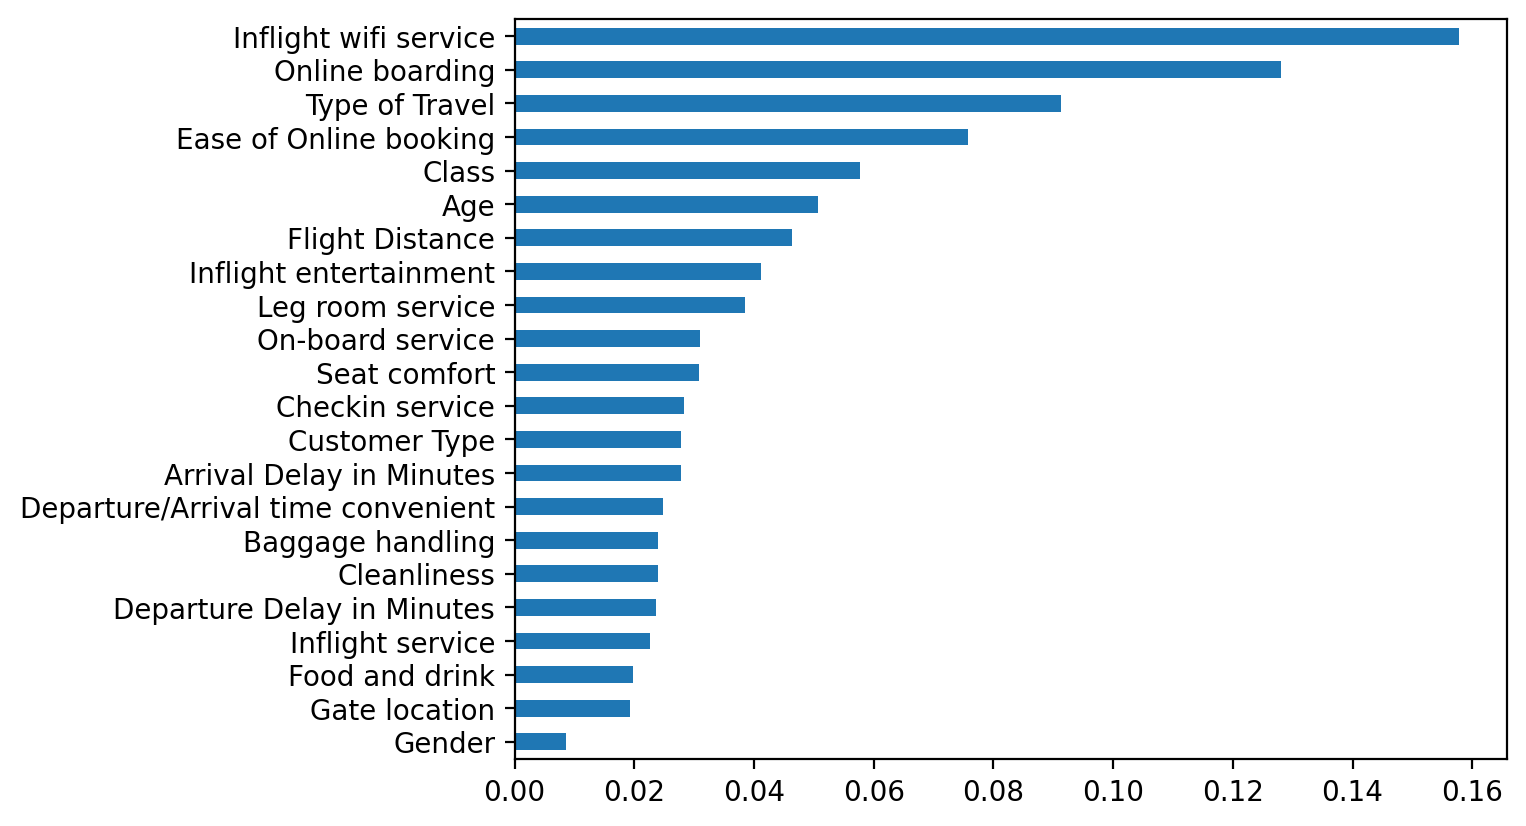

In [631]:
imp = pd.Series(model.feature_importances_, index=list(x))
imp.sort_values(ascending=True).plot(kind='barh')
plt.show()

### (4) 결과 정리

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [632]:
# 1. Inflight wifi service
# 2. Online boarding
# 3. Type of Travel
# 4. Ease of Online booking
# 5. Class

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [633]:
# 1. Gender
# 2. Customer Type
# 3. Departure/Arrival time convenient
# 4. Food and drink
# 5. Gate location

## **5. 미션 4: 머신러닝 모델링 #2**

- 35세를 기준으로 데이터를 분리해 각각에 대한 모델을 만들어봅니다.

### (1) 데이터 분리

- 더 세분화할 수 있지만, 35세를 기준으로 두 개의 데이터프레임을 만듭니다.
    - **data01**: Age <= 35
    - **data02**: Age > 35

In [634]:
# 데이터 분리

data01 = data[data['Age'] <= 35 ]
data02 = data[data['Age'] > 35 ]

In [635]:
data01.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Satisfaction
0,1,1,35.0,0,1,349,5.0,1,1,1,...,5,4,2,2,3,1,5,0,0.0,1
4,1,1,33.0,0,0,3153,0.0,5,0,4,...,3,3,4,1,1,2,3,0,0.0,1
5,0,0,23.0,0,0,1068,5.0,0,5,5,...,4,4,2,5,3,4,4,9,17.0,1
13,1,1,34.0,0,0,2849,4.0,2,4,4,...,2,2,2,2,3,2,3,1,0.0,1
18,0,1,34.0,0,0,516,4.0,4,2,4,...,5,5,5,5,4,5,4,0,0.0,1


### (2) 35세 이하 모델링

- **data01** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [636]:
target = 'Satisfaction'

x = data01.drop(target, axis=1)
y = data01.loc[ : , target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [637]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)

- 모델링을 수행합니다.

In [638]:
model = RandomForestClassifier()

model.fit(x_train,y_train)

RandomForestClassifier()

In [639]:
y_pred = model.predict(x_test)

In [640]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[ 227   52]
 [   9 1461]]
              precision    recall  f1-score   support

           0       0.96      0.81      0.88       279
           1       0.97      0.99      0.98      1470

    accuracy                           0.97      1749
   macro avg       0.96      0.90      0.93      1749
weighted avg       0.97      0.97      0.96      1749



- 변수 중요도를 확인합니다.

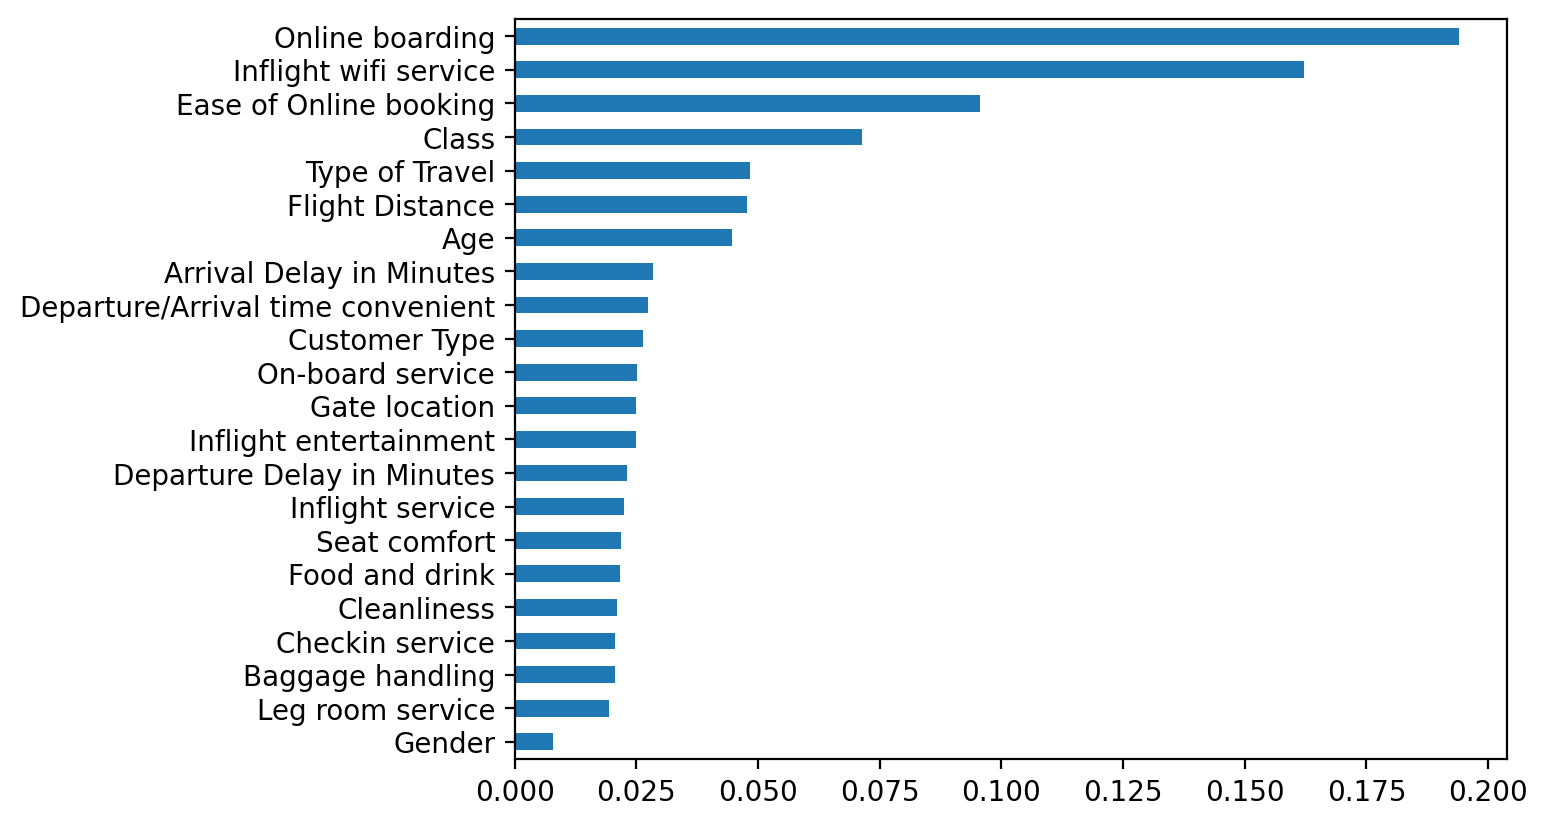

In [641]:
imp = pd.Series(model.feature_importances_, index=list(x))
imp.sort_values(ascending=True).plot(kind='barh')
plt.show()

- 중요하다고 확인된 변수 5개는 무엇인가요?


In [642]:
# 1. Online boarding
# 2. Inflight wifi service
# 3. Ease of Online booking
# 4. Type of Travel
# 5. Class

- 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [643]:
# 1. Gender
# 2. Seat comfort
# 3. Leg room service
# 4. Baggage handlling
# 5. Cleanliness

### (3) 35세 초과 모델링

- **data02** 데이터프레임을 대상으로 모델링을 수행합니다.
- 우선 target 변수를 선정하고 x, y를 분리합니다.

In [644]:
target = 'Satisfaction'

x = data02.drop(target, axis=1)
y = data02.loc[:,target]

- 학습용, 검증용 데이터를 7:3으로 분리합니다.

In [645]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.3, random_state=1)

- 모델링을 수행합니다.

In [646]:
model = RandomForestClassifier()

model.fit(x_train, y_train)

RandomForestClassifier()

In [647]:
y_pred = model.predict(x_test)

In [648]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[ 236   85]
 [  28 3686]]
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       321
           1       0.98      0.99      0.98      3714

    accuracy                           0.97      4035
   macro avg       0.94      0.86      0.90      4035
weighted avg       0.97      0.97      0.97      4035



- 변수 중요도를 확인합니다.

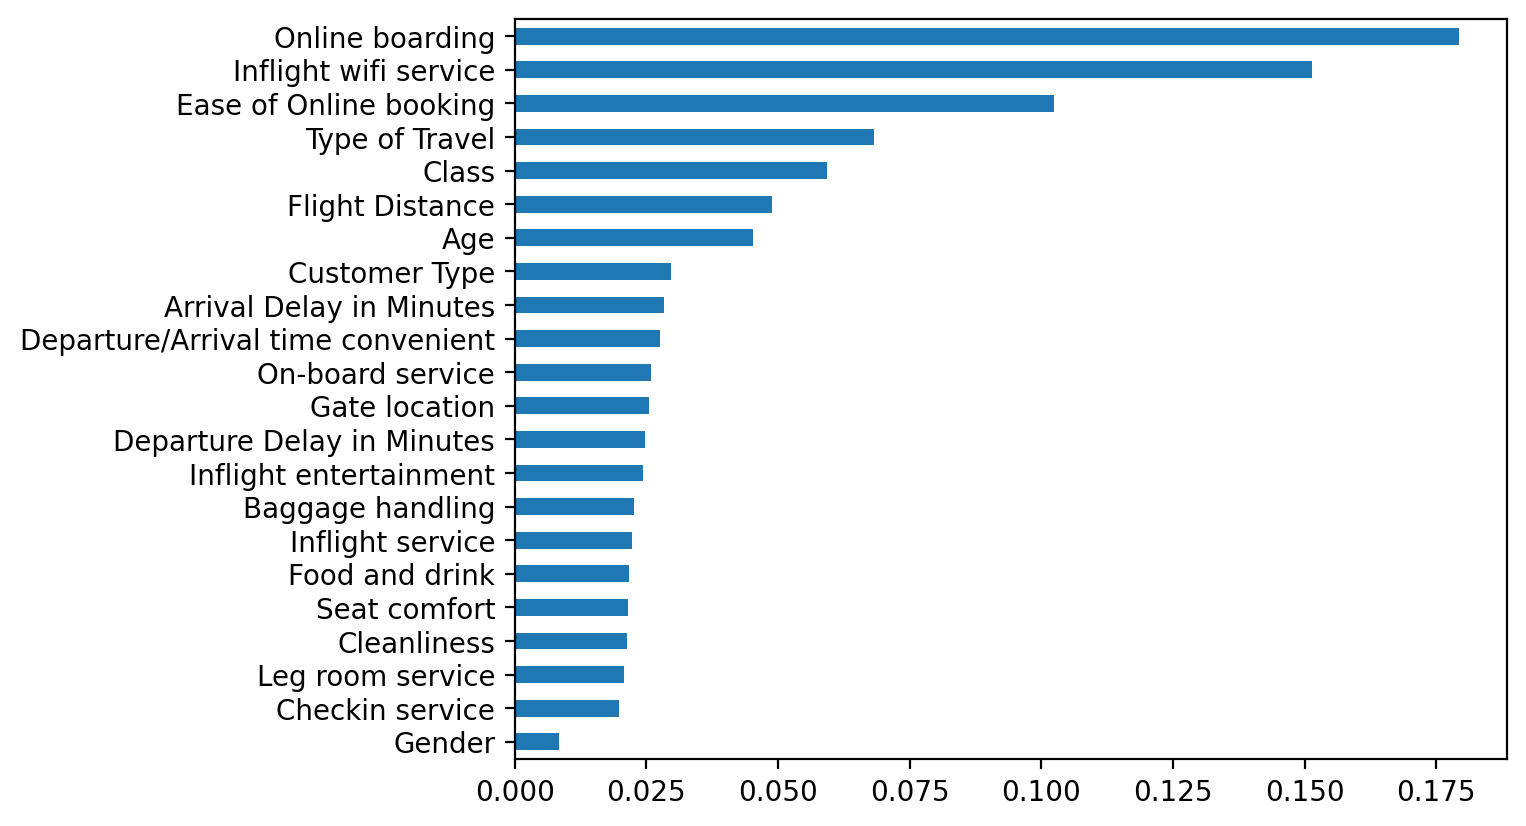

In [649]:
imp = pd.Series(model.feature_importances_, index=list(x))
importance.sort_values(ascending=True).plot(kind='barh')
plt.show()

- 가장 중요하다고 확인된 변수 5개는 무엇인가요?


In [650]:
# 1. Online boarding
# 2. Inflight wifi service
# 3. Ease of Online booking
# 4. Type of Travel
# 5. Class

- 가장 중요하지 않다고 확인된 변수 5개는 무엇인가요?

In [651]:
# 1. Gender
# 2. Checkin service
# 3. Leg room service
# 4. Cleanliness
# 5. Seat comfort

### (4) 의견 정리

- 위 모델링 과정과 변수 중요도 확인 과정 결과에 대한 의견을 정리합니다.

In [652]:
# Online boarding , Inflight wifi service , Ease of Online booking , Type of Travel , Class 가 중요 변수
#
#

## **6. 미션 5: 데이터 분석**

- 위에서 확인된 변수 중요도를 기준으로 분석할 변수를 5개 선정하고 분석을 수행합니다.
- **data** 데이터프레임을 대상으로 분석합니다.
- Satisfaction 변수와의 **이변량 분석**에 중점을 두고 수행합니다.
- 각 분석 결과에 대한 의견을 주석으로 정리합니다.

In [653]:
print(data['Online boarding'].value_counts())
print(data['Inflight wifi service'].value_counts())
print(data['Ease of Online booking'].value_counts())
print(data['Type of Travel'].value_counts())
print(data['Class'].value_counts())

Online boarding
4    7851
5    6965
3    1764
2    1269
1     893
0     536
Name: count, dtype: int64
Inflight wifi service
4.0    5350
5.0    4192
3.0    3112
2.0    3022
1.0    2494
0.0    1108
Name: count, dtype: int64
Ease of Online booking
4    4301
5    4039
3    3539
2    3382
1    2845
0    1172
Name: count, dtype: int64
Type of Travel
0    17061
1     2217
Name: count, dtype: int64
Class
0    13782
1     4609
2      887
Name: count, dtype: int64


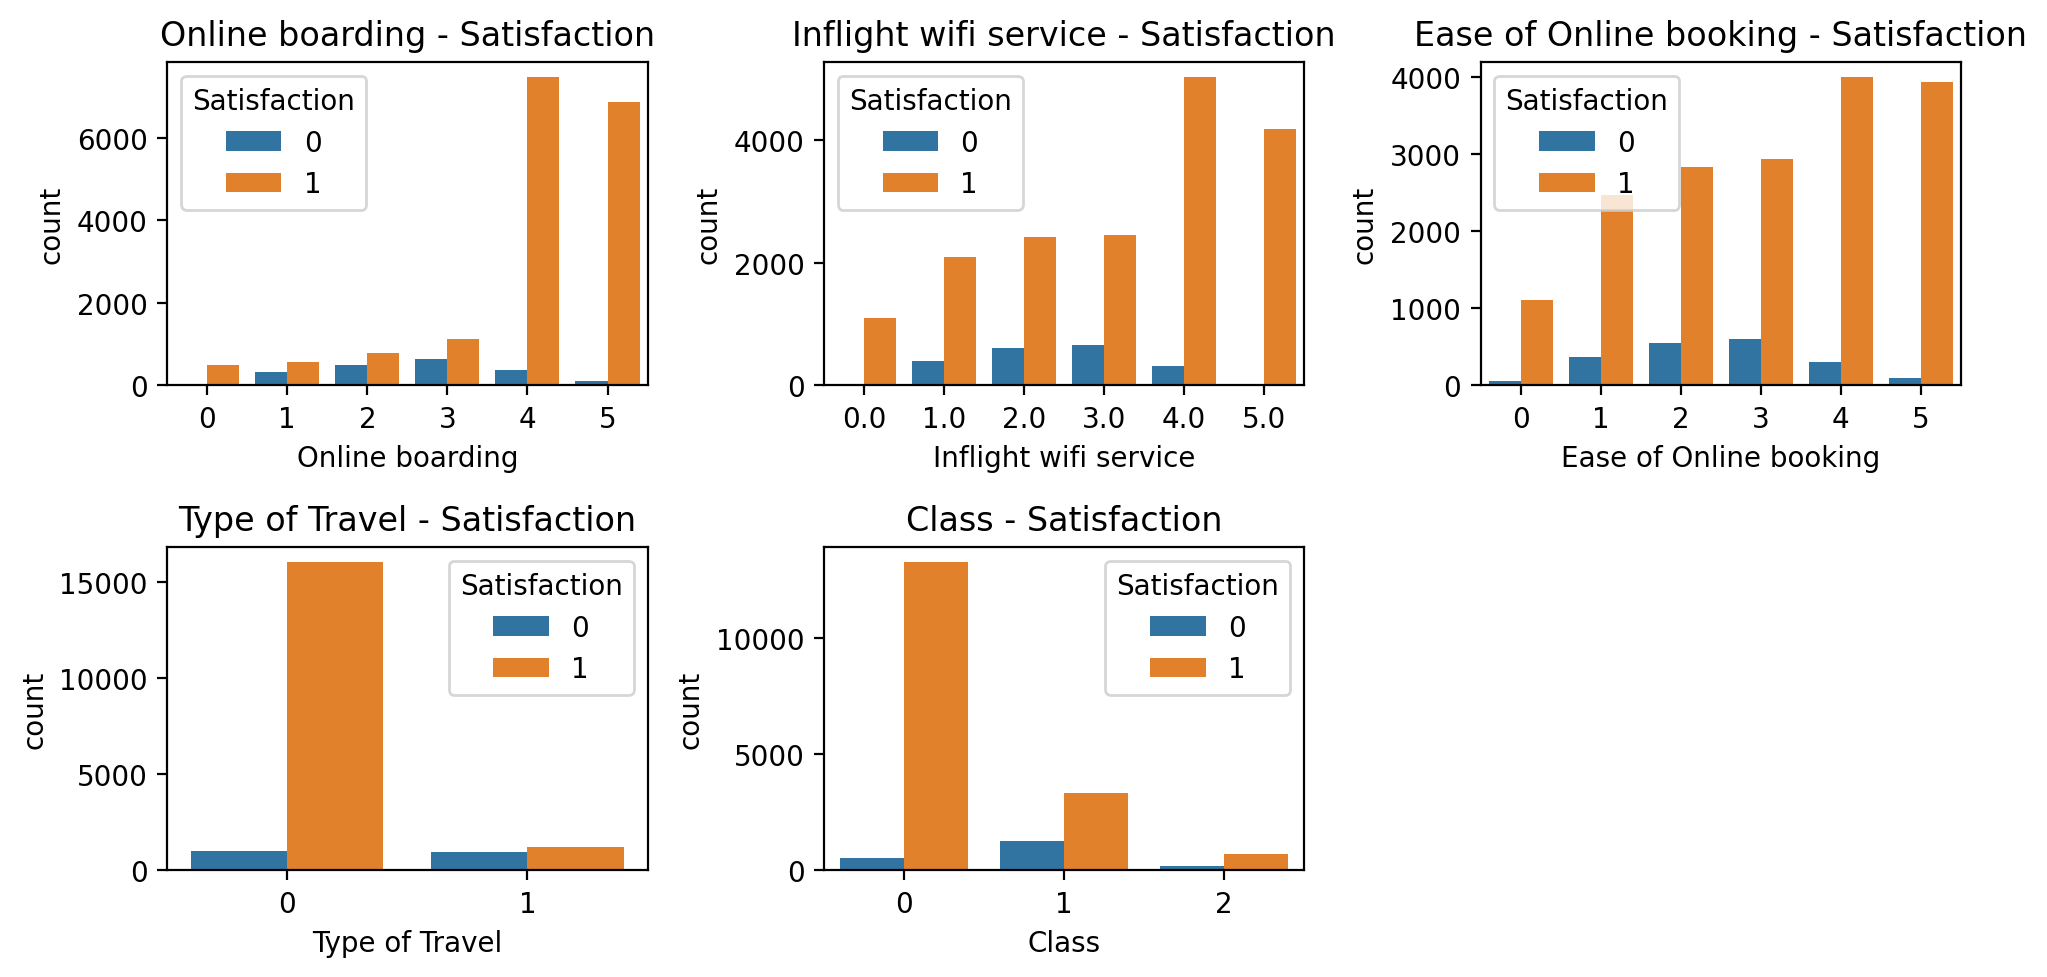

In [654]:
plt.figure(figsize=(10,5))

plt.subplot(2,3,1)
sns.countplot(x='Online boarding' , hue='Satisfaction', data=data)
plt.title('Online boarding - Satisfaction')

plt.subplot(2,3,2)
sns.countplot(x='Inflight wifi service' , hue='Satisfaction', data=data)
plt.title('Inflight wifi service - Satisfaction')

plt.subplot(2,3,3)
sns.countplot(x='Ease of Online booking' , hue='Satisfaction', data=data)
plt.title('Ease of Online booking - Satisfaction')

plt.subplot(2,3,4)
sns.countplot(x='Type of Travel' , hue='Satisfaction', data=data)
plt.title('Type of Travel - Satisfaction')

plt.subplot(2,3,5)
sns.countplot(x='Class' , hue='Satisfaction', data=data)
plt.title('Class - Satisfaction')

plt.tight_layout()
plt.show()

## **7. 저장하기**

- **to_csv()** 메서드를 사용해 이후 과정을 위해 data 데이터프레임을 **project01** 폴더에 저장합니다.
    - index=False 옵션 지정
    - data → path + 'data.csv'
    
- 저장된 파일을 필히 확인합니다.

In [655]:
# 파일 저장
data.to_csv(path + 'data.csv', index=False)